<div style="display: flex; background-color: #5B6C9F;" >
<h1 style="margin: auto; padding: 30px; color: white; ">Detecting counterfeit banknotes - Notebook 1 - Analysis and modelling</h1>
</div>

<div style="background-color: #C97B63;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Step 1 - Importing libraries and loading the files</h2>
</div>

<div style="border: 1px solid #C97B63;" >
<h3 style="margin: auto; padding: 20px; color: #5B6C9F; ">1.1 - Importing libraries</h3>
</div>

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

<div style="border: 1px solid #C97B63;" >
<h3 style="margin: auto; padding: 20px; color: #5B6C9F; ">1.2 - Importing the file</h3>
</div>

In [2]:
# Load the file
df_billets = pd.read_csv("../data/billets.csv", sep=";")

<div style="background-color: #C97B63;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Step 2 - Exploratory analysis of the file</h2>
</div>

<div style="border: 1px solid #C97B63;" >
<h3 style="margin: auto; padding: 20px; color: #5B6C9F; ">2.1 - Exploring the file</h3>
</div>

In [3]:
# Dataset dimensions
df_billets.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB


The margin_low variable has 37 missing values; all the others are complete. The dataset is 1,500 × 7.

In [4]:
# First 5 rows
df_billets.head(5)

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


In [5]:
# Descriptive statistics of the size variables
df_billets.describe()

,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000000,1500.000000,1500.000000,1463.000000,1500.000000,1500.00000
mean,171.958440,104.029533,103.920307,4.485967,3.151473,112.67850
std,0.305195,0.299462,0.325627,0.663813,0.231813,0.87273
min,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000
25%,171.750000,103.820000,103.710000,4.015000,2.990000,112.03000
50%,171.960000,104.040000,103.920000,4.310000,3.140000,112.96000
75%,172.170000,104.230000,104.150000,4.870000,3.310000,113.34000
max,173.010000,104.880000,104.950000,6.900000,3.910000,114.44000


The banknotes are fairly homogeneous, with very small standard deviations (margin_up: 0.23, the lowest; length: 0.82, the highest). No obvious outliers at first sight (to be confirmed with boxplots). There are, however, significant differences between the means and standard deviations of the variables, which justifies standardising them (StandardScaler) so that each variable contributes equally, especially for models such as k-means or logistic regression.

In [6]:
# Size variables
taille = [
    "diagonal",
    "height_left",
    "height_right",
    "margin_low",
    "margin_up",
    "length",
]

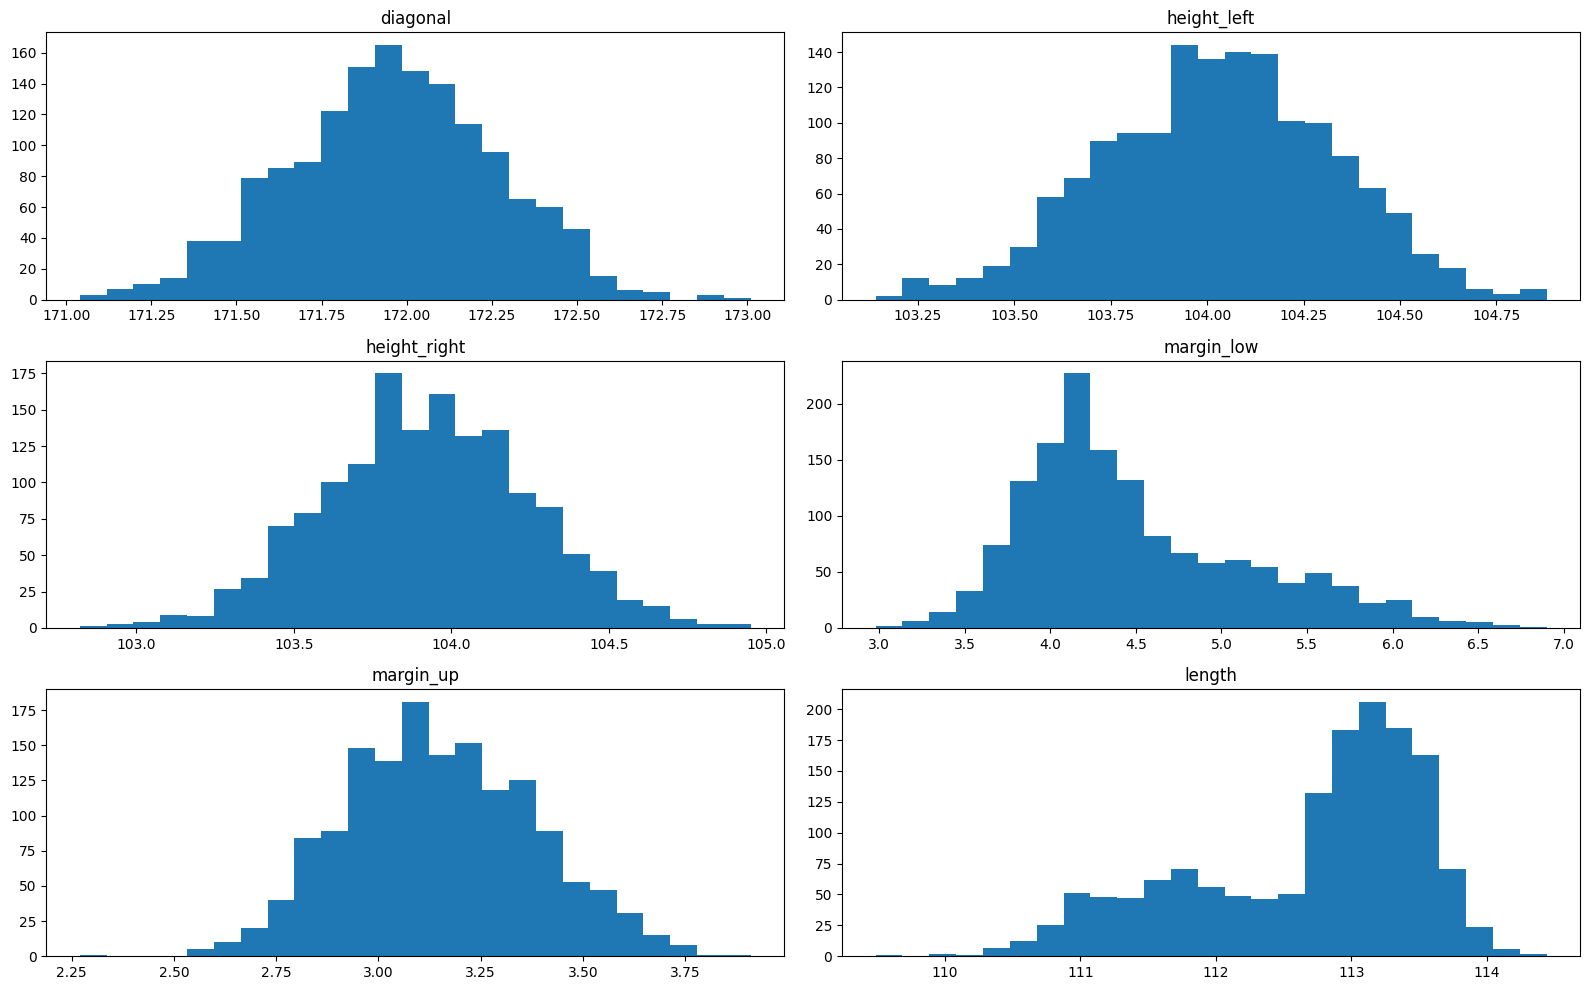

In [7]:
# Plot the distribution of the variables
df_billets[taille].hist(bins=25, figsize=(16, 10), grid=False)
plt.tight_layout()
plt.show()

- Most variables (diagonal, height_left, height_right, margin_up) have a unimodal, broadly symmetrical distribution, suggesting a normal distribution. Genuine and counterfeit notes seem to overlap without clear separation, so these variables alone do not seem able to tell a genuine note from a fake.
 - margin_low, although unimodal, is right-skewed, suggesting two distinct groups, possibly the genuine and the counterfeit notes. length is bimodal, suggesting strong discriminating power, with two populations that do not mix.
 - These visual observations and hypotheses call for a correlation analysis.

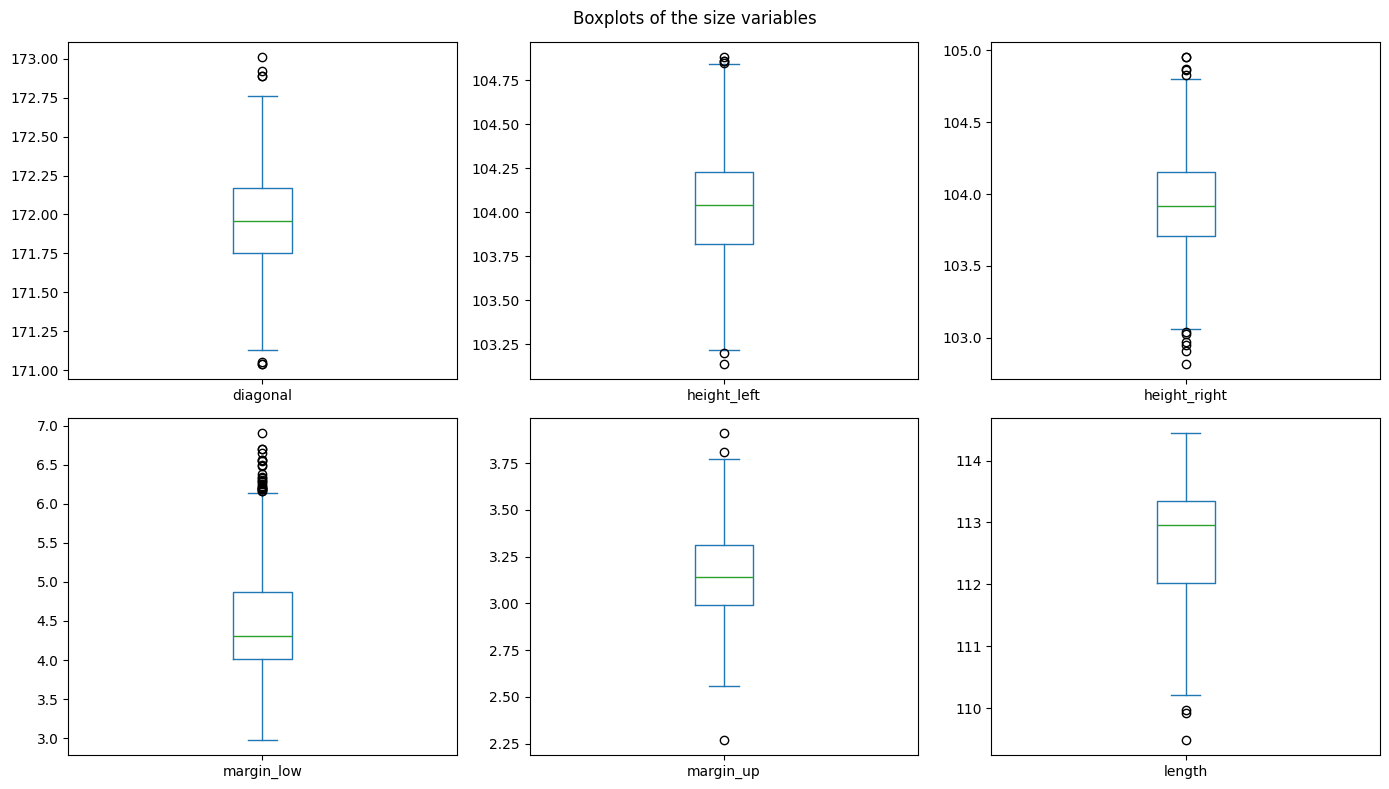

In [8]:
# Boxplots of the size variables
df_billets[taille].plot(kind="box", subplots=True, layout=(2, 3), figsize=(14, 8))
plt.suptitle("Boxplots of the size variables")
plt.tight_layout()
plt.show()

- Some outliers, but no negative values.
  - Several points lie beyond the whiskers, particularly on margin_low, which is consistent with the skew seen on its histogram.
  Here, the extreme points are not errors: they correspond to atypical dimensions, most likely counterfeit notes. All values are therefore kept, because these outliers are the fuel of our future prediction algorithms. Removing them would remove useful signal for telling genuine notes from fakes.

<div style="border: 1px solid #C97B63;" >
<h3 style="margin: auto; padding: 20px; color: #5B6C9F; ">2.2 - Correlations between variables and with the target (is_genuine)</h3>
</div>

In [9]:
# Encode the target as numbers
df_billets["cible"] = df_billets["is_genuine"].astype(int)

In [10]:
# Size variables + target
taille_cible = [
    "diagonal",
    "height_left",
    "height_right",
    "margin_low",
    "margin_up",
    "length",
    "cible",
]

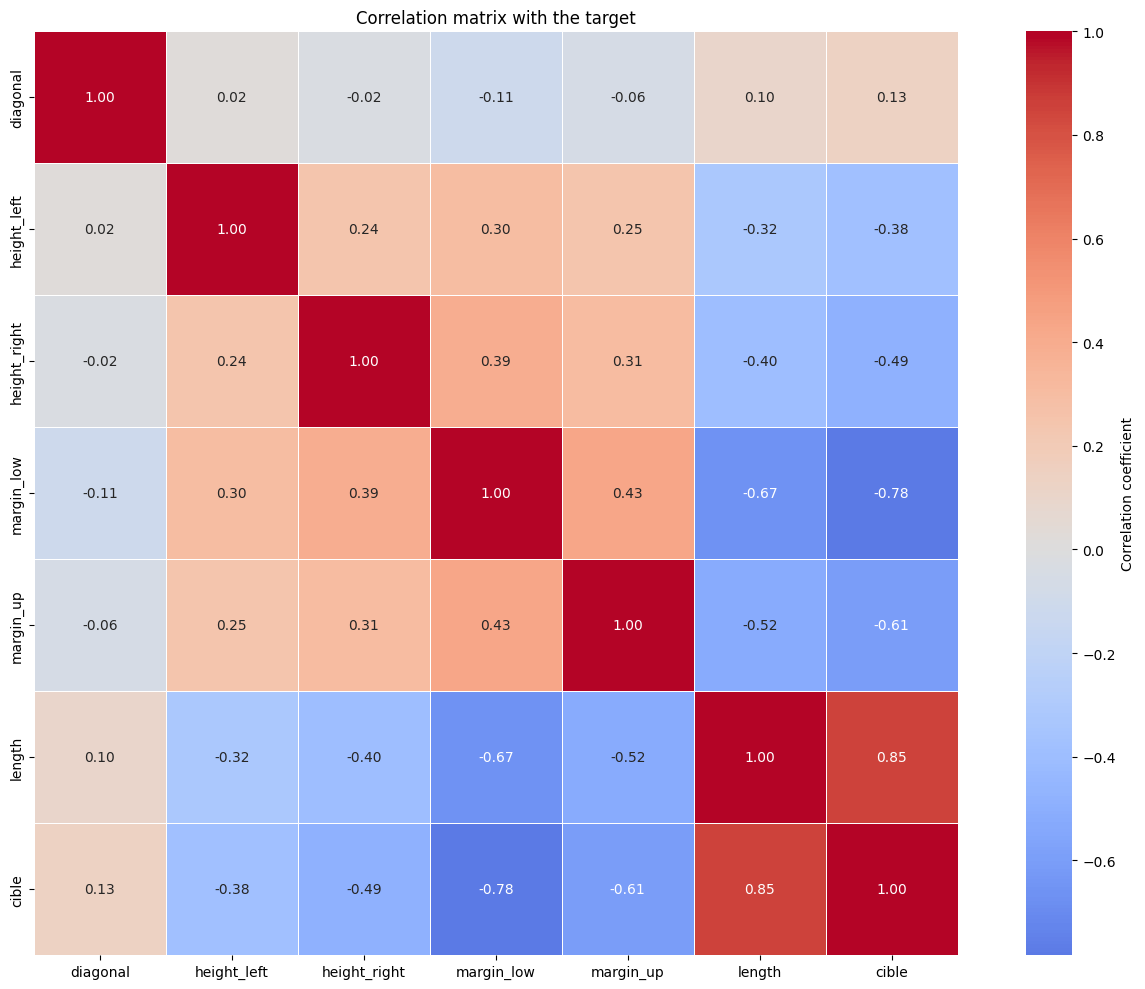

In [11]:
# Correlation heatmap including the target
plt.figure(figsize=(14, 10))
sns.heatmap(
    df_billets[taille_cible].corr(),
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlation coefficient"},
)
plt.title("Correlation matrix with the target")
plt.tight_layout()
plt.show()

1- Correlations between variables:
 - No strong redundancy appears in the correlation matrix, so all variables can be kept.
  - diagonal is the most independent variable in the dataset, with no correlation with the others.
  - margin_low and length are strongly negatively correlated (-0.67), the strongest correlation in the matrix: when one increases, the other decreases. This correlation will let us use a linear regression to impute the missing values of margin_low.

2- Correlations with the target:
- length (0.85) and margin_low (-0.78) are by far the most discriminating, followed by margin_up (-0.61), height_right (-0.49) and height_left (-0.38). diagonal is almost completely independent and nearly useless (0.13).
- The sign gives the direction: length is positive, so genuine notes are longer, while margin_low and margin_up are negative, so genuine notes have smaller margins.
- This matrix confirms the hypotheses made when studying the distributions: length and margin_low are the most discriminating, and margin_up also separates genuine from fake notes, which the histograms did not reveal.

<div style="border: 1px solid #C97B63;" >
<h3 style="margin: auto; padding: 20px; color: #5B6C9F; ">2.3 - Share of genuine and counterfeit notes</h3>
</div>

In [12]:
# Count genuine / counterfeit notes
print(df_billets["is_genuine"].value_counts())

is_genuine
True     1000
False     500
Name: count, dtype: int64


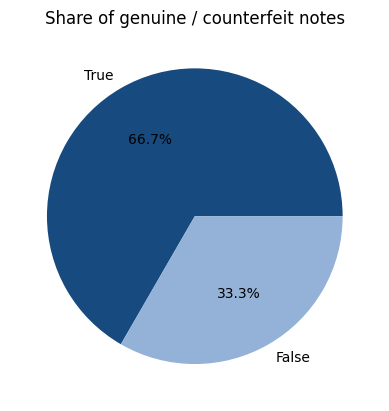

In [13]:
# Share of genuine / counterfeit notes
df_billets["is_genuine"].value_counts().plot(
    kind="pie", colors=["#174A7E", "#94B2D7"], autopct="%1.1f%%"
)
plt.title("Share of genuine / counterfeit notes")
plt.show()

The dataset contains 1,500 banknotes: 1,000 genuine and 500 counterfeit, i.e. one third fake and two thirds genuine.

<div style="background-color: #C97B63;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Step 3 - Preparing the data</h2>
</div>

<div style="border: 1px solid #C97B63;" >
<h3 style="margin: auto; padding: 20px; color: #5B6C9F; ">3.1 - Imputing missing values</h3>
</div>

In [14]:
# Import linear regression
from sklearn.linear_model import LinearRegression

In [15]:
# Variables used to predict margin_low
predicteurs = ["diagonal", "height_left", "height_right", "margin_up", "length"]

In [16]:
# Separate complete notes from those to fill in
connu = df_billets[df_billets["margin_low"].notna()]
manquant = df_billets[df_billets["margin_low"].isna()]

In [17]:
# Train the linear regression
reg_imput = LinearRegression()
reg_imput.fit(connu[predicteurs], connu["margin_low"])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
# Predict margin_low where it is missing
valeurs_predites = reg_imput.predict(manquant[predicteurs])

In [19]:
# Insert the predicted values
df_billets.loc[df_billets["margin_low"].isna(), "margin_low"] = valeurs_predites

In [20]:
# Check the imputation
print("Valeurs manquantes restantes:", df_billets["margin_low"].isna().sum())

Valeurs manquantes restantes: 0


<div style="border: 1px solid #C97B63;" >
<h3 style="margin: auto; padding: 20px; color: #5B6C9F; ">3.2 - Splitting X and y</h3>
</div>

In [21]:
X = df_billets[taille]
y = df_billets["cible"]

<div style="border: 1px solid #C97B63;" >
<h3 style="margin: auto; padding: 20px; color: #5B6C9F; ">3.3 - Train / test split</h3>
</div>

In [22]:
# Import train_test_split
from sklearn.model_selection import train_test_split

In [23]:
# 80% train / 20% test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [24]:
# Check
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (1200, 6) | Test: (300, 6)


The explanatory variables (X) and the target (y) were successfully separated, and the dataset was split in two: a training set of 1,200 notes and a test set of 300 notes, each with 6 variables.
The stratify=y parameter strictly preserves the original proportion of genuine and counterfeit notes in both sets.

<div style="border: 1px solid #C97B63;" >
<h3 style="margin: auto; padding: 20px; color: #5B6C9F; ">3.4 - Standardisation</h3>
</div>

In [25]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

In [26]:
# Standardisation
scaler = StandardScaler()

In [27]:
# Fit and transform the training set
x_train_scaled = scaler.fit_transform(X_train)

In [28]:
# Rebuild the training dataframe
x_train_scaled = pd.DataFrame(
    x_train_scaled, columns=X_train.columns, index=X_train.index
)

In [29]:
# First 5 rows of the standardised training set
x_train_scaled.head()

,diagonal,height_left,height_right,margin_low,margin_up,length
122,-0.498491,-2.706699,0.002898,-0.765730,-0.397979,0.748396
875,-0.065093,0.194914,-1.984348,-0.781060,-0.094757,0.989435
941,0.568335,-2.273124,0.779166,-0.397813,0.511688,0.449967
494,0.401643,0.528433,0.344456,-0.581772,-0.701202,0.955000
186,0.835041,-1.839550,0.375507,-0.137206,-0.657884,0.553270


In [30]:
# Check the scaling with the mean and standard deviation
x_train_scaled.describe().round(2).loc[["mean", "std"]]

,diagonal,height_left,height_right,margin_low,margin_up,length
mean,0.0,-0.0,0.0,-0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0


In [31]:
# Transform the test set
x_test_scaled = scaler.transform(X_test)

In [32]:
# Rebuild the test dataframe
x_test_scaled = pd.DataFrame(x_test_scaled, columns=X_test.columns, index=X_test.index)

The test set is only transformed, never fitted, so as not to bias the evaluation of the model by giving it information about the data it is supposed to discover.

In [33]:
x_test_scaled.describe().round(2).loc[["mean", "std"]]

,diagonal,height_left,height_right,margin_low,margin_up,length
mean,-0.02,-0.03,0.02,-0.05,-0.01,0.06
std,1.08,0.99,1.05,1.05,1.02,1.01


- The data is now ready for the prediction algorithms. Missing values were imputed by linear regression.
  - The dataset was split into two parts: a training set (80%) and a test set (20%).
   - The explanatory variables of the training set (X_train) were fitted and transformed, as confirmed by means of 0 and standard deviations of 1.
   - The explanatory variables of the test set (X_test) were only transformed, not fitted, to keep our future models impartial.

<div style="background-color: #C97B63;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Step 4 - Logistic regression</h2>
</div>

In [34]:
# Import logistic regression
from sklearn.linear_model import LogisticRegression

In [35]:
# Initialise the logistic regression
reg_log = LogisticRegression(max_iter=1000, random_state=42)

In [36]:
# Train on the training set
reg_log.fit(x_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

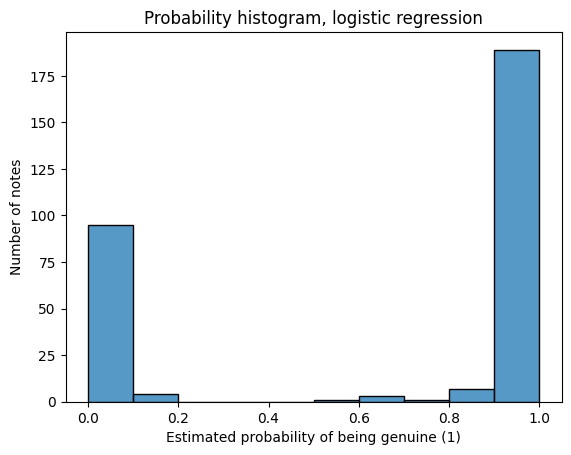

In [37]:
# Probability histogram, logistic regression
reg_hist_proba = reg_log.predict_proba(x_test_scaled)[:, 1]
sns.histplot(reg_hist_proba)
plt.title("Probability histogram, logistic regression")
plt.xlabel("Estimated probability of being genuine (1)")
plt.ylabel("Number of notes")
plt.show()

- This histogram shows the model's confidence for each banknote in the test set.
  - The peak on the left, near 0.0, gathers the notes the algorithm identifies as counterfeit; the peak on the right, near 1.0, the notes identified as genuine.
  - This bimodal distribution is ideal: the centre of the chart is almost empty, which shows that the algorithm almost never hesitates when separating counterfeit from genuine notes.

In [38]:
# Predictions on the test set
y_pred_log = reg_log.predict(x_test_scaled)

In [39]:
# Accuracy score
from sklearn.metrics import accuracy_score

ac_reg_log = accuracy_score(y_test, y_pred_log)
ac_reg_log

0.99

The accuracy score of 0.99 confirms what the probability histogram showed: the model reaches 99% accuracy on the test data and separates genuine from counterfeit notes firmly and with high confidence. Let's now check whether the model is biased or balanced.

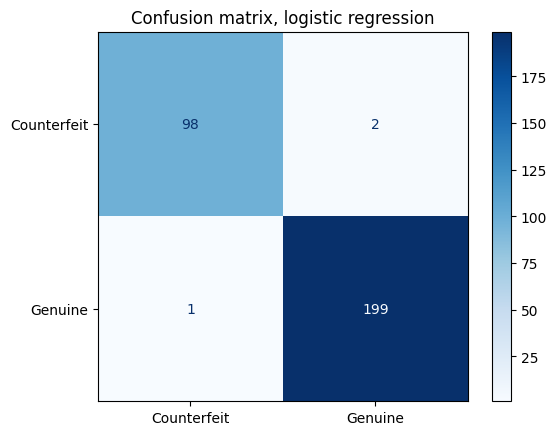

In [40]:
# Confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_log, display_labels=["Counterfeit", "Genuine"], cmap="Blues"
)
plt.title("Confusion matrix, logistic regression")
plt.xlabel("")
plt.ylabel("")
plt.show()

- True negatives: 98 notes correctly identified as counterfeit
 - True positives: 199 notes correctly identified as genuine
 - False positives: 2 counterfeit notes wrongly classified as genuine (undetected fakes)
 - False negatives: 1 genuine note wrongly classified as counterfeit

 The model correctly predicted 297 notes out of 300: this first model is extremely accurate.
 Although the confusion matrix shows excellent performance, we will confirm the model's robustness with the ROC curve and its AUC score.

AUC score: 0.9995


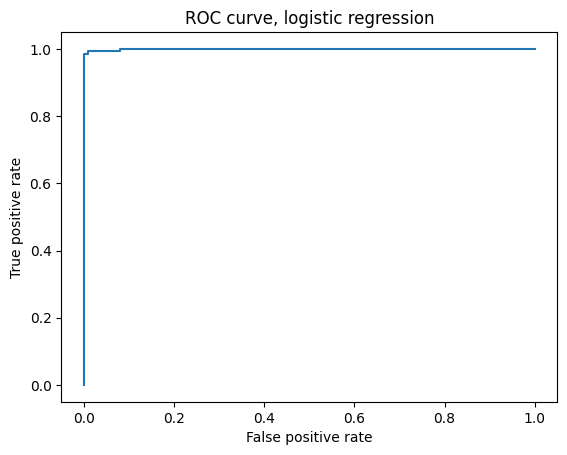

In [41]:
# AUC score and ROC curve
from sklearn.metrics import roc_curve, roc_auc_score

auc = roc_auc_score(y_test, reg_hist_proba)
print(f"AUC score: {auc:.4f}")
frp, tpr, thresholds = roc_curve(y_test, reg_hist_proba)
plt.plot(frp, tpr)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve, logistic regression")
plt.show()

- The ROC curve and the AUC score of 0.9995 confirm the quality of this model.
 - The AUC score is extremely close to 1, which mathematically confirms that the algorithm can almost flawlessly distinguish between the two types of banknotes.
 - The ROC curve draws a near-perfect right angle towards the top-left corner: the model detects almost all genuine notes (very high true positive rate) while almost never accepting a counterfeit (near-zero false positive rate).

This chart crowns the performance of our logistic regression. The model is 99% accurate, extremely robust, balanced, and ready to be applied to new data.

<div style="background-color: #C97B63;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Step 5 - K-means</h2>
</div>

In [42]:
# Import k-means
from sklearn.cluster import KMeans

Unlike a classic exploratory clustering, where we would look for the optimal number of groups, here we already know the target: 2 clusters, genuine and counterfeit. K-means is therefore set directly to two clusters.

In [43]:
# K-means with 2 clusters
kmeans2 = KMeans(n_clusters=2, random_state=42, n_init="auto")
kmeans2.fit(x_train_scaled)
clusters = kmeans2.predict(x_test_scaled)

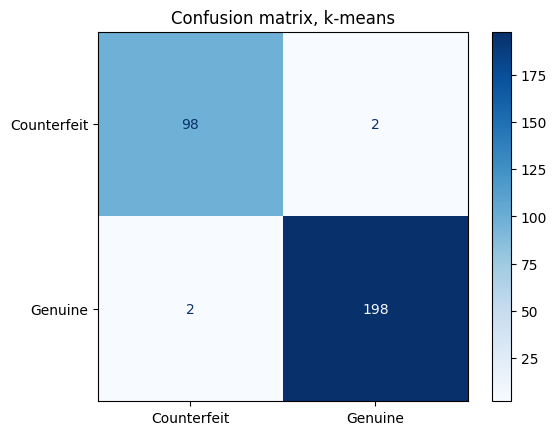

In [44]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, clusters, display_labels=["Counterfeit", "Genuine"], cmap="Blues"
)
plt.title("Confusion matrix, k-means")
plt.xlabel("")
plt.ylabel("")
plt.show()

- True negatives: 98 notes correctly identified as counterfeit
 - True positives: 198 notes correctly identified as genuine
 - False positives: 2 counterfeit notes wrongly classified as genuine (undetected fakes)
 - False negatives: 2 genuine notes wrongly classified as counterfeit

 The model made only 4 assignment errors on the 300 test notes, which is extremely accurate: only one more error than the logistic regression.

In [45]:
# Accuracy score

ac_kmeans = accuracy_score(y_test, clusters)
ac_kmeans

0.9866666666666667

The accuracy score is very close to 1 (0.987), showing that the algorithm is very precise at deciding whether a note is genuine or counterfeit.

K-means proved very reliable, with very few assignment errors and near-perfect accuracy. Despite this strong performance, it remains slightly behind the logistic regression, which is still our model of choice at this stage.

<div style="background-color: #C97B63;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Step 6 - K-Nearest Neighbors (KNN)</h2>
</div>

In [46]:
# Import KNN
from sklearn.neighbors import KNeighborsClassifier

KNN is set with K = 3: for a binary classification, an odd number avoids ties between the two classes. Looking at the 3 nearest notes guarantees that an absolute majority always emerges to make the decision.

In [47]:
# Initialise KNN with K=3 and train it
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


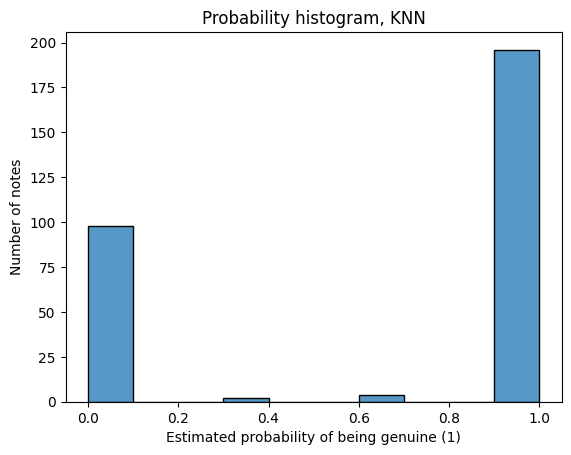

In [48]:
# Probability histogram, KNN
knn_hist_proba = knn.predict_proba(x_test_scaled)[:, 1]
sns.histplot(knn_hist_proba)
plt.title("Probability histogram, KNN")
plt.xlabel("Estimated probability of being genuine (1)")
plt.ylabel("Number of notes")
plt.show()

Unlike the logistic regression, KNN has slightly more difficulty deciding for a few small groups of notes around 0.4 and 0.6. The model nevertheless remains very accurate, with two large bars at the extremes (0.0 and 1.0).

In [49]:
# Predict the test set
y_pred_knn = knn.predict(x_test_scaled)

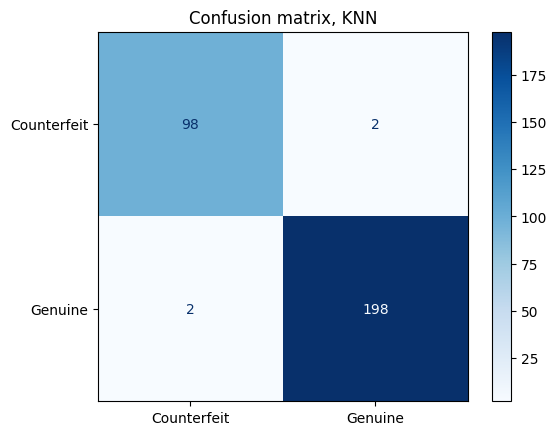

In [50]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_knn, display_labels=["Counterfeit", "Genuine"], cmap="Blues"
)
plt.title("Confusion matrix, KNN")
plt.xlabel("")
plt.ylabel("")
plt.show()

- True negatives: 98 notes correctly identified as counterfeit
 - True positives: 198 notes correctly identified as genuine
 - False positives: 2 counterfeit notes wrongly classified as genuine (undetected fakes)
 - False negatives: 2 genuine notes wrongly classified as counterfeit

 The model made only 4 assignment errors on the 300 notes, the same result as k-means.

In [51]:
# Accuracy score
ac_knn = accuracy_score(y_test, y_pred_knn)
ac_knn

0.9866666666666667

The accuracy score is also identical to the previous model (0.987), showing that this model is very accurate as well.

AUC score: 0.9972


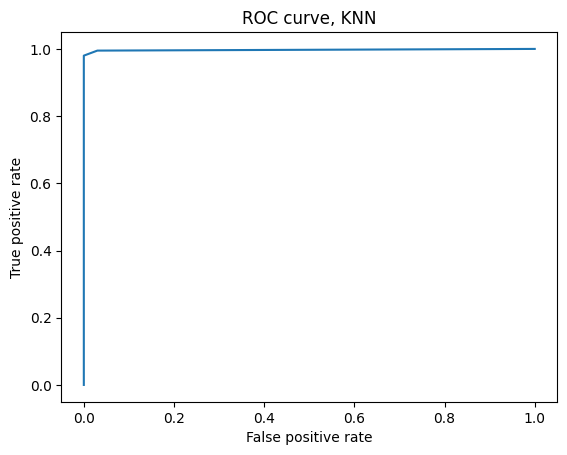

In [52]:
# AUC score and ROC curve
auc_knn = roc_auc_score(y_test, knn_hist_proba)
print(f"AUC score: {auc_knn:.4f}")
frp_knn, tpr_knn, thresholds_knn = roc_curve(y_test, knn_hist_proba)
plt.plot(frp_knn, tpr_knn)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve, KNN")
plt.show()

- To validate the model's robustness, we computed its ROC curve and AUC score, and both are remarkable.
 - The AUC score of 0.9972 is very close to 1, indicating an almost perfect model that distinguishes genuine from counterfeit notes with very few errors.
 - The ROC curve draws a near-perfect right angle in the top-left corner, showing that the model is close to bullet-proof.

KNN proves extremely accurate, with results identical to those of k-means. However remarkable, they remain very slightly behind the logistic regression, which is still the best performer.

<div style="background-color: #C97B63;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Step 7 - Random Forest</h2>
</div>

In [53]:
# Import Random Forest
from sklearn.ensemble import RandomForestClassifier

In [54]:
# Initialise the model
rf = RandomForestClassifier(n_estimators=100, random_state=42)

In [55]:
# Train on the data
rf.fit(x_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

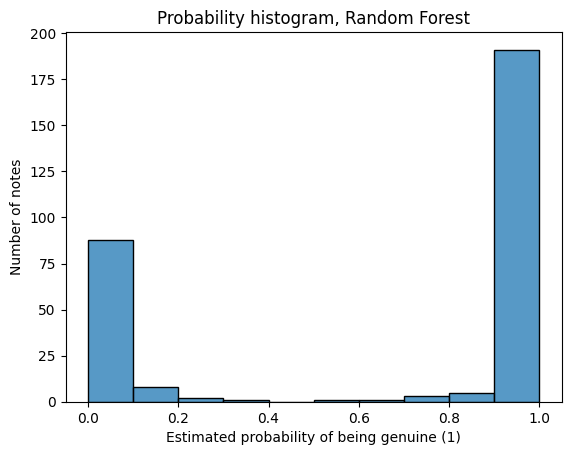

In [56]:
# Probability histogram, Random Forest
rf_hist_proba = rf.predict_proba(x_test_scaled)[:, 1]
sns.histplot(rf_hist_proba)
plt.title("Probability histogram, Random Forest")
plt.xlabel("Estimated probability of being genuine (1)")
plt.ylabel("Number of notes")
plt.show()

The Random Forest probability histogram shows that the model is extremely confident in its choices: the vast majority of notes are classified at the two extremes (0.0 and 1.0). Compared with the logistic regression, there are slightly more small steps between the extremes, due to ensemble learning with 100 decision trees.

In [57]:
# Predictions on the test set
y_pred_rf = rf.predict(x_test_scaled)

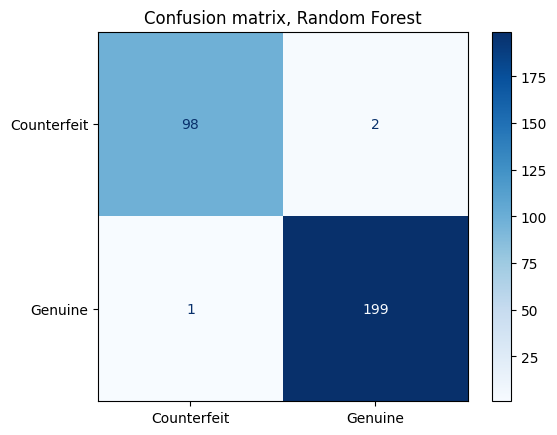

In [58]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, display_labels=["Counterfeit", "Genuine"], cmap="Blues"
)
plt.title("Confusion matrix, Random Forest")
plt.xlabel("")
plt.ylabel("")
plt.show()

- True negatives: 98 notes correctly identified as counterfeit
 - True positives: 199 notes correctly identified as genuine
 - False positives: 2 counterfeit notes wrongly classified as genuine (undetected fakes)
 - False negatives: 1 genuine note wrongly classified as counterfeit

 The model correctly predicted 297 notes out of 300: this confusion matrix is identical to the logistic regression's.

In [59]:
# Accuracy score
ac_rf = accuracy_score(y_test, y_pred_rf)
ac_rf

0.99

The accuracy score of 0.99 shows that this model is almost perfectly reliable at identifying counterfeits.

AUC score: 0.9994


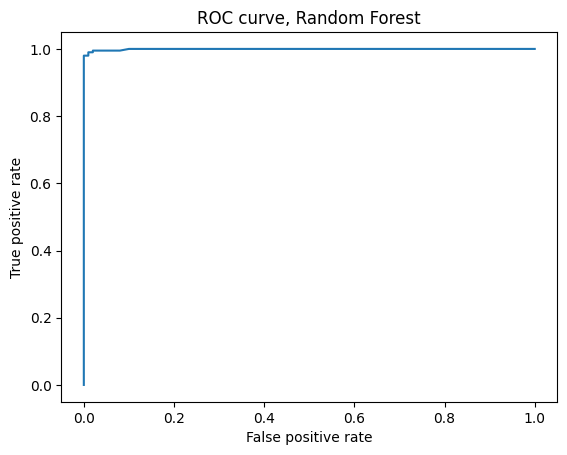

In [60]:
# AUC score and ROC curve
auc_rf = roc_auc_score(y_test, rf_hist_proba)
print(f"AUC score: {auc_rf:.4f}")
frp_rf, tpr_rf, thresholds_rf = roc_curve(y_test, rf_hist_proba)
plt.plot(frp_rf, tpr_rf)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve, Random Forest")
plt.show()

- The ROC curve draws a near-perfect right angle, with very slight dips in the top-left corner like our other models, showing that all of them can determine the nature of a note while almost never raising a false alarm. Since the logistic regression and the Random Forest are almost identical in every respect (confusion matrix, accuracy and ROC curve), our final criterion to separate them is the AUC score: 0.9994 for the Random Forest and 0.9995 for the logistic regression.
 - Although Random Forest is known for its power, our discriminating variables separate the classes in a simple, monotonic way. This near-linear structure makes the logistic regression as accurate as the Random Forest, while being simpler.
 - According to the principle of parsimony, also known as Occam's razor, at equal performance the simplest model should always be preferred: it is faster, easier to interpret and less prone to overfitting. Logistic regression is therefore the model we keep.

<div style="background-color: #C97B63;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Step 8 - Saving the best model</h2>
</div>

In [61]:
# Import make_pipeline and joblib
from sklearn.pipeline import make_pipeline
import joblib

In [62]:
# Build and train the final pipeline (StandardScaler + logistic regression) to export
pipeline_final = make_pipeline(
    StandardScaler(), LogisticRegression(max_iter=1000, random_state=42)
)
pipeline_final.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some 

In [63]:
# Save the model
joblib.dump(pipeline_final, "../model/counterfeit_detection_model.joblib")

['../model/counterfeit_detection_model.joblib']